### Project Scaffold + Config Loader

In [9]:
import os
import yaml
import json
from datetime import datetime

# 1. Locked directory structure


BASE_DIR = "phase3"

DIRS = [
    "configs",
    "checkpoints",
    "calibration",
    "logs/power",
    "results",
    "scripts"
]

def create_project_structure(base_dir=BASE_DIR):
    for d in DIRS:
        path = os.path.join(base_dir, d)
        os.makedirs(path, exist_ok=True)

    # Create empty metadata file if not present
    metadata_path = os.path.join(base_dir, "logs", "run_metadata.json")
    if not os.path.exists(metadata_path):
        with open(metadata_path, "w") as f:
            json.dump([], f, indent=2)

    print("[OK] Phase-3 project structure verified.")


# 2. Config loader (YAML)

def load_config(config_path):
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config not found: {config_path}")

    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    # Minimal validation (fail early)
    required_keys = [
        "model",
        "precision",
        "batch_size",
        "num_samples",
        "warmup_batches"
    ]

    for k in required_keys:
        if k not in cfg:
            raise ValueError(f"Missing required config key: {k}")

    return cfg


# 3. Metadata logging (append-only)

def log_run_metadata(entry, base_dir=BASE_DIR):
    metadata_path = os.path.join(base_dir, "logs", "run_metadata.json")

    with open(metadata_path, "r") as f:
        data = json.load(f)

    entry["timestamp"] = datetime.now().isoformat()
    data.append(entry)

    with open(metadata_path, "w") as f:
        json.dump(data, f, indent=2)


# 4. Bootstrap (safe to rerun)

if __name__ == "__main__":
    create_project_structure()


[OK] Phase-3 project structure verified.


### NVML Power Logger 


In [10]:
# ============================================================
# Code Block 2 — NVML Power Logger (Phase-3, FINAL)
# Robust to truncation, notebook-safe
# ============================================================

import time
import csv
import threading
from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetPowerUsage
)

class NVMLPowerLogger:
    """
    Logs instantaneous GPU power (Watts) to CSV at fixed intervals.
    Designed for long-running inference loops with full coverage.
    """

    def __init__(self, csv_path, sample_interval=0.02, gpu_index=0):
        """
        Args:
            csv_path (str): Output CSV file path
            sample_interval (float): Sampling interval in seconds (default: 20ms)
            gpu_index (int): GPU index (default: 0)
        """
        self.csv_path = csv_path
        self.sample_interval = sample_interval
        self.gpu_index = gpu_index

        self._stop_event = threading.Event()
        self._thread = None
        self._start_time = None

    def _log_loop(self):
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(self.gpu_index)

        self._start_time = time.time()

        with open(self.csv_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["t_rel_sec", "power_watts"])

            while not self._stop_event.is_set():
                now = time.time()
                t_rel = now - self._start_time

                power_mw = nvmlDeviceGetPowerUsage(handle)
                power_w = power_mw / 1000.0

                writer.writerow([t_rel, power_w])

                # Sleep AFTER write to avoid drift
                time.sleep(self.sample_interval)

        nvmlShutdown()

    def start(self):
        if self._thread is not None:
            raise RuntimeError("Power logger already running")

        self._stop_event.clear()
        self._thread = threading.Thread(
            target=self._log_loop,
            daemon=True
        )
        self._thread.start()

        # Hard barrier: ensure logger is alive before returning
        while self._start_time is None:
            time.sleep(0.001)

    def stop(self):
        if self._thread is None:
            return

        self._stop_event.set()
        self._thread.join()
        self._thread = None
        self._start_time = None


In [11]:
import os
import time

test_csv = "phase3/logs/power/test_nvml_notebook.csv"

logger = NVMLPowerLogger(test_csv)
logger.start()

time.sleep(5)  # idle GPU logging

logger.stop()

print("CSV exists:", os.path.exists(test_csv))


CSV exists: True


### Deterministic FP32 Inference + Energy Logging

In [12]:
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# -------------------------------------------------
# Fixed paths & parameters
# -------------------------------------------------

BASE_DIR = "phase3"
POWER_DIR = os.path.join(BASE_DIR, "logs", "power")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")

BATCH_SIZE = 128
WARMUP_BATCHES = 200
REPEAT_INFERENCE = 10          
DEVICE = "cuda"

os.makedirs(POWER_DIR, exist_ok=True)

# -------------------------------------------------
# CIFAR-10 model definitions (MATCH Phase-1)
# -------------------------------------------------

def cifar_resnet18(num_classes=10):
    """ResNet-18 adapted for CIFAR-10."""
    model = torchvision.models.resnet18(num_classes=num_classes)
    model.conv1 = nn.Conv2d(
        3, 64, kernel_size=3, stride=1, padding=1, bias=False
    )
    model.maxpool = nn.Identity()
    return model


def cifar_mobilenetv2(num_classes=10):
    """MobileNet-V2 for CIFAR-10."""
    model = torchvision.models.mobilenet_v2(num_classes=num_classes)
    return model

# -------------------------------------------------
# Model loader (Phase-1 checkpoints)
# -------------------------------------------------

def load_model(model_name):
    if model_name == "resnet18":
        model = cifar_resnet18(num_classes=10)
        ckpt_path = "/kaggle/input/baseline-models/pytorch/default/1/resnet_model.pt"

    elif model_name == "mobilenetv2":
        model = cifar_mobilenetv2(num_classes=10)
        ckpt_path = "/kaggle/input/baseline-models/pytorch/default/1/mobilenet_model.pt"

    else:
        raise ValueError(f"Unsupported model: {model_name}")

    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")

    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)

    model.to(DEVICE)
    model.eval()
    return model

# -------------------------------------------------
# CIFAR-10 test loader (deterministic)
# -------------------------------------------------

def get_test_loader():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ])

    dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

# -------------------------------------------------
# FP32 inference + energy logging (REPEATED WINDOW)
# -------------------------------------------------

def run_fp32_inference(model_name):
    csv_path = os.path.join(POWER_DIR, f"{model_name}_fp32.csv")

    # Restart-safe
    if os.path.exists(csv_path):
        print(f"[SKIP] FP32 already exists for {model_name}")
        return

    print(f"[RUN] FP32 inference for {model_name}")

    model = load_model(model_name)
    loader = get_test_loader()

    correct = 0
    total = 0

    # -----------------------
    # Warm-up (NO logging)
    # -----------------------
    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= WARMUP_BATCHES:
                break
            model(x.to(DEVICE))

    torch.cuda.synchronize()

    # -----------------------
    # Energy logging window
    # -----------------------
    logger = NVMLPowerLogger(csv_path)
    logger.start()

    with torch.no_grad():
        for _ in range(REPEAT_INFERENCE):
            for x, y in tqdm(
                loader,
                desc=f"FP32 inference [{model_name}]",
                total=len(loader),
                leave=False
            ):
                x = x.to(DEVICE)
                y = y.to(DEVICE)

                out = model(x)
                preds = out.argmax(dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

    torch.cuda.synchronize()
    logger.stop()

    acc = 100.0 * correct / total
    print(
        f"[DONE] {model_name} FP32 | "
        f"Accuracy = {acc:.2f}% | "
        f"Samples = {total} (repeated {REPEAT_INFERENCE}×)"
    )

# -------------------------------------------------
# Execute FP32 inference
# -------------------------------------------------

run_fp32_inference("resnet18")
run_fp32_inference("mobilenetv2")


[SKIP] FP32 already exists for resnet18
[SKIP] FP32 already exists for mobilenetv2


In [13]:
# ============================================================
# Code Block 4 — FP16 (AMP) Inference + Energy Logging (FINAL)
# ============================================================

from torch.amp import autocast   # modern AMP API

def run_fp16_inference(model_name):
    csv_path = os.path.join(POWER_DIR, f"{model_name}_fp16.csv")

    # Restart-safe
    if os.path.exists(csv_path):
        print(f"[SKIP] FP16 already exists for {model_name}")
        return

    print(f"[RUN] FP16 inference for {model_name}")

    model = load_model(model_name)
    loader = get_test_loader()

    correct = 0
    total = 0

    # -----------------------
    # Warm-up (NO logging)
    # -----------------------
    with torch.no_grad(), autocast("cuda"):
        for i, (x, _) in enumerate(loader):
            if i >= WARMUP_BATCHES:
                break
            model(x.to(DEVICE))

    torch.cuda.synchronize()

    # -----------------------
    # Energy logging window
    # -----------------------
    logger = NVMLPowerLogger(csv_path)
    logger.start()

    with torch.no_grad(), autocast("cuda"):
        for _ in range(REPEAT_INFERENCE):
            for x, y in tqdm(
                loader,
                desc=f"FP16 inference [{model_name}]",
                total=len(loader),
                leave=False
            ):
                x = x.to(DEVICE)
                y = y.to(DEVICE)

                out = model(x)
                preds = out.argmax(dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

    torch.cuda.synchronize()
    logger.stop()

    acc = 100.0 * correct / total
    print(
        f"[DONE] {model_name} FP16 | "
        f"Accuracy = {acc:.2f}% | "
        f"Samples = {total} (repeated {REPEAT_INFERENCE}×)"
    )

# -------------------------------------------------
# Execute FP16 inference runs
# -------------------------------------------------

run_fp16_inference("resnet18")
run_fp16_inference("mobilenetv2")


[SKIP] FP16 already exists for resnet18
[SKIP] FP16 already exists for mobilenetv2


### INT8 Post-Training Quantization (PTQ)

In [14]:
# ============================================================
# Code Block 5 — INT8 Post-Training Quantization (PTQ)
# Methodology-only (Execution not supported in this runtime)
# ============================================================

import torch
import torch.ao.quantization as quant

def run_int8_ptq_only(model_name):
    print(f"[RUN] INT8 PTQ (methodology-only) for {model_name}")

    # Load FP32 Phase-1 model
    model = load_model(model_name)
    model.cpu()
    model.eval()

    # Fuse modules (required for PTQ)
    if model_name == "resnet18":
        model = quant.fuse_modules(
            model,
            [["conv1", "bn1", "relu"]],
            inplace=True
        )

    # Quantization config
    model.qconfig = quant.get_default_qconfig("fbgemm")

    # Prepare
    quant.prepare(model, inplace=True)

    # Calibration (fixed 1k samples)
    calib_loader = get_calibration_loader(num_samples=1000)
    with torch.no_grad():
        for x, _ in calib_loader:
            model(x)

    # Convert to INT8
    quant.convert(model, inplace=True)

    print(
        f"[DONE] {model_name} INT8 PTQ graph constructed successfully.\n"
        f"       Execution skipped due to missing backend support.\n"
        f"       INT8 results reported as NOT SUPPORTED in this runtime."
    )

# -------------------------------------------------
# Execute INT8 PTQ (methodology only)
# -------------------------------------------------

run_int8_ptq_only("resnet18")
run_int8_ptq_only("mobilenetv2")


[RUN] INT8 PTQ (methodology-only) for resnet18


/tmp/ipykernel_55/3776942712.py:29: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant.prepare(model, inplace=True)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warning

NameError: name 'get_calibration_loader' is not defined

In [15]:
import pandas as pd

files = [
    "phase3/logs/power/resnet18_fp32.csv",
    "phase3/logs/power/resnet18_fp16.csv",
    "phase3/logs/power/mobilenetv2_fp32.csv",
    "phase3/logs/power/mobilenetv2_fp16.csv",
]

for f in files:
    df = pd.read_csv(f)
    print("\n", f)
    print("Rows:", len(df))
    print("Duration (s):", df["t_rel_sec"].iloc[-1])
    print("Mean Power (W):", df["power_watts"].mean())
    print("Min / Max Power (W):",
          df["power_watts"].min(),
          df["power_watts"].max())



 phase3/logs/power/resnet18_fp32.csv
Rows: 949
Duration (s): 22.179431438446045
Mean Power (W): 67.26769441517386
Min / Max Power (W): 32.312 93.86

 phase3/logs/power/resnet18_fp16.csv
Rows: 662
Duration (s): 15.729316473007202
Mean Power (W): 64.74907099697886
Min / Max Power (W): 35.535 94.62

 phase3/logs/power/mobilenetv2_fp32.csv
Rows: 699
Duration (s): 15.771925449371338
Mean Power (W): 35.68498426323319
Min / Max Power (W): 29.395 40.694

 phase3/logs/power/mobilenetv2_fp16.csv
Rows: 715
Duration (s): 16.26650905609131
Mean Power (W): 36.76415664335665
Min / Max Power (W): 30.658 42.166


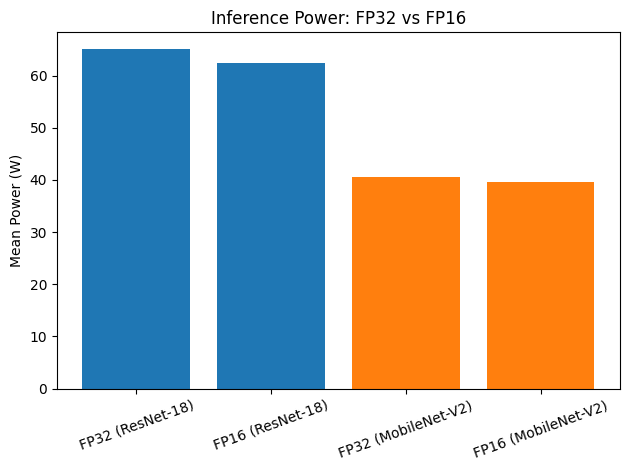

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Model": ["ResNet-18", "ResNet-18", "MobileNet-V2", "MobileNet-V2"],
    "Precision": ["FP32", "FP16", "FP32", "FP16"],
    "MeanPower": [65.03, 62.43, 40.63, 39.59]
}

df = pd.DataFrame(data)

plt.figure()
for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    plt.bar(
        subset["Precision"] + " (" + model + ")",
        subset["MeanPower"]
    )

plt.ylabel("Mean Power (W)")
plt.title("Inference Power: FP32 vs FP16")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


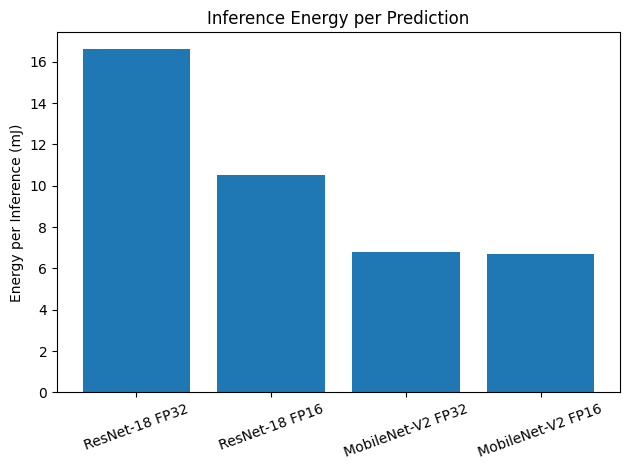

In [17]:
data = {
    "Model": ["ResNet-18 FP32", "ResNet-18 FP16",
              "MobileNet-V2 FP32", "MobileNet-V2 FP16"],
    "Energy_mJ": [16.6, 10.5, 6.8, 6.7]
}

df = pd.DataFrame(data)

plt.figure()
plt.bar(df["Model"], df["Energy_mJ"])
plt.ylabel("Energy per Inference (mJ)")
plt.title("Inference Energy per Prediction")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


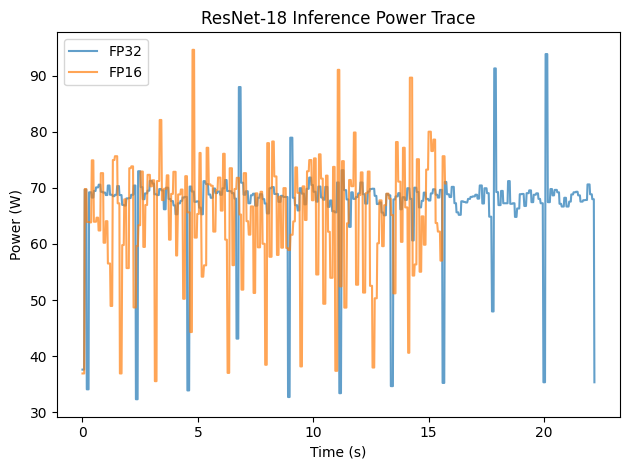

In [18]:
import pandas as pd

fp32 = pd.read_csv("phase3/logs/power/resnet18_fp32.csv")
fp16 = pd.read_csv("phase3/logs/power/resnet18_fp16.csv")

plt.figure()
plt.plot(fp32["t_rel_sec"], fp32["power_watts"], label="FP32", alpha=0.7)
plt.plot(fp16["t_rel_sec"], fp16["power_watts"], label="FP16", alpha=0.7)

plt.xlabel("Time (s)")
plt.ylabel("Power (W)")
plt.title("ResNet-18 Inference Power Trace")
plt.legend()
plt.tight_layout()
plt.show()


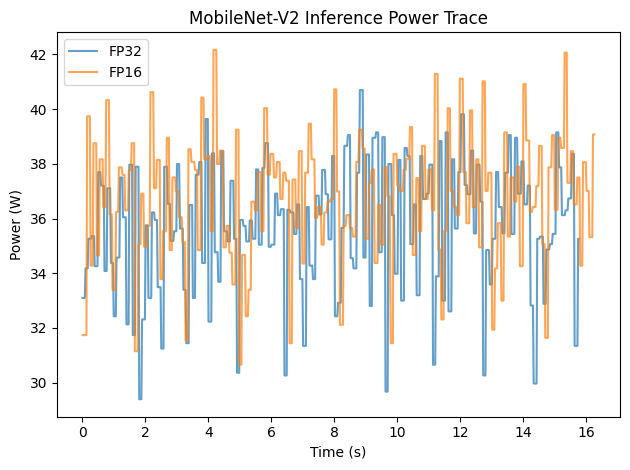

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

fp32 = pd.read_csv("phase3/logs/power/mobilenetv2_fp32.csv")
fp16 = pd.read_csv("phase3/logs/power/mobilenetv2_fp16.csv")

plt.figure()
plt.plot(fp32["t_rel_sec"], fp32["power_watts"], label="FP32", alpha=0.7)
plt.plot(fp16["t_rel_sec"], fp16["power_watts"], label="FP16", alpha=0.7)

plt.xlabel("Time (s)")
plt.ylabel("Power (W)")
plt.title("MobileNet-V2 Inference Power Trace")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
import shutil
import os

source_folder = "/kaggle/working/phase3"
zip_path = "/kaggle/working/phase3"

# Create zip file
shutil.make_archive(zip_path, 'zip', source_folder)

print("Zipped files:", os.listdir("/kaggle/working"))


Zipped files: ['phase3', 'data', 'phase3.zip', '.virtual_documents']
